/var/folders/yn/2tfz0n9x7m3dkwb69m05y8lw0000gn/T/ipykernel_13925/397743986.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


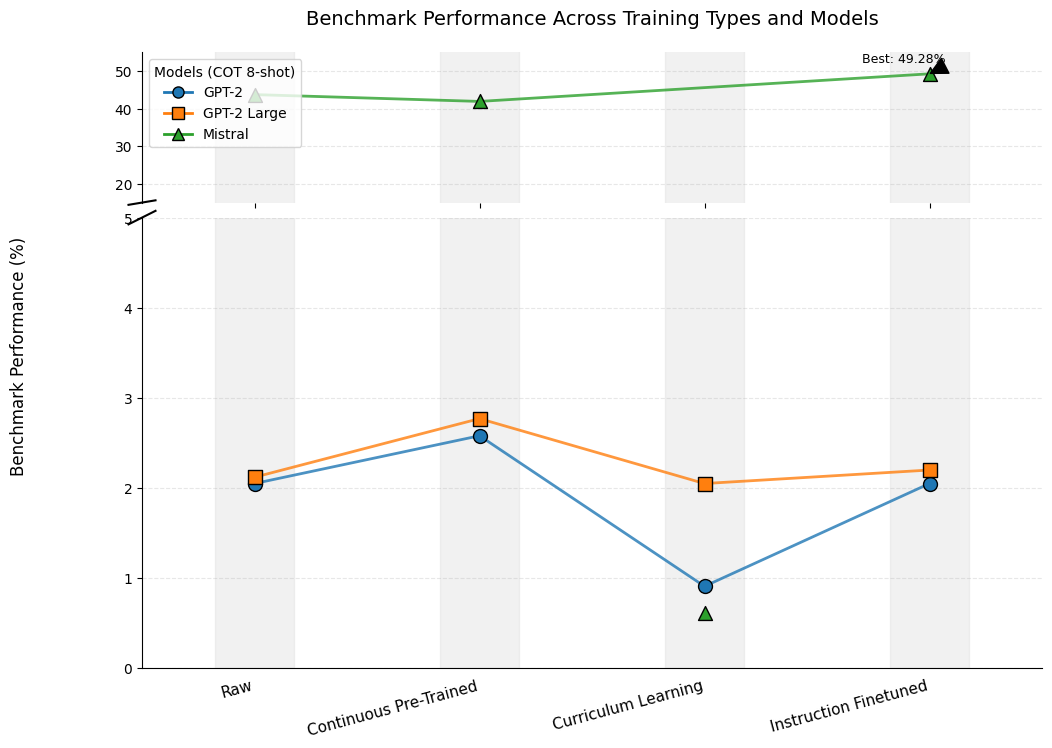

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file with the full path
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with two subplots to simulate an axis break
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), 
                              gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05})

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    ax1.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 100, 
                              color='lightgray', alpha=0.3, zorder=0))
    ax2.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 100, 
                              color='lightgray', alpha=0.3, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            
            # Plot COT points on appropriate subplot based on value
            if cot > 5:
                ax1.scatter(x_pos, cot, 
                           color=model_colors[model], marker=model_markers[model], 
                           s=100, zorder=3, edgecolors='black', linewidth=1)
            else:
                ax2.scatter(x_pos, cot, 
                           color=model_colors[model], marker=model_markers[model], 
                           s=100, zorder=3, edgecolors='black', linewidth=1)

# Now add connecting lines between training types for the same model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Split data for upper and lower plot
    upper_x = []
    upper_y = []
    lower_x = []
    lower_y = []
    
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        if y > 5:
            upper_x.append(x)
            upper_y.append(y)
        else:
            lower_x.append(x)
            lower_y.append(y)
    
    # Draw lines in upper plot
    if len(upper_x) > 1:
        ax1.plot(upper_x, upper_y, color=model_colors[model], linestyle='-', 
                 linewidth=2, alpha=0.8, zorder=2)
    
    # Draw lines in lower plot
    if len(lower_x) > 1:
        ax2.plot(lower_x, lower_y, color=model_colors[model], linestyle='-', 
                 linewidth=2, alpha=0.8, zorder=2)

# Set y-axis limits with some padding
ax1.set_ylim(15, 55)  # Upper part
ax2.set_ylim(0, 5)    # Lower part

# Hide spines that aren't needed
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)  # Hide right spine
ax2.spines['right'].set_visible(False)  # Hide right spine
ax1.spines['top'].set_visible(False)    # Remove top boundary line

# Add diagonal lines ONLY on the left side to indicate the break
d = .015  # Size of diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal only

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal only

# Set x-axis labels but remove ticks
ax2.set_xticks(list(training_positions.values()))
# Rotate labels for better readability
ax2.set_xticklabels(list(training_positions.keys()), fontsize=11, rotation=15, ha='right')
ax2.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with some padding
ax2.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis ticks

# Set a single y-axis label for the entire figure
fig.text(0.04, 0.5, 'Benchmark Performance (%)', va='center', rotation='vertical', fontsize=12)
# Remove individual y-axis labels
ax1.set_ylabel('')
ax2.set_ylabel('')

# Create a custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                       label=model, markersize=8, linestyle='-', linewidth=2,
                       markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend
ax1.legend(handles=model_legend, 
          loc='upper left', fontsize=10, title="Models (COT 8-shot)")

# Title
ax1.set_title('Benchmark Performance Across Training Types and Models', fontsize=14, pad=20)

# Add grid lines for readability
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Annotate interesting points or insights
# For example, highlight the best performing configuration
max_idx = np.argmax([max(data['y']) for model, data in model_data.items()])
best_model = list(models)[max_idx]
best_value = max(model_data[best_model]['y'])
best_training_idx = model_data[best_model]['y'].index(best_value)
best_training = list(training_types)[best_training_idx]

# Add an annotation for the best performance
ax1.annotate(f"Best: {best_value:.2f}%",
            xy=(model_data[best_model]['x'][best_training_idx], best_value),
            xytext=(model_data[best_model]['x'][best_training_idx]-0.3, best_value+3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=9)

# Adjust layout
plt.tight_layout()
# Add more space on the left for the y-axis label
plt.subplots_adjust(left=0.15)

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()